Predict the price of the Uber ride from a given pickup point to 
the agreed drop-off 
location. Perform following tasks: 
1. Pre-process the dataset. 
2. Identify outliers. 
3. Check the correlation. 
4. Implement linear regression and random forest regression 
models. 
Evaluate the models and compare their respective scores like R2, 
RMSE, etc. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#import data
data = pd.read_csv("uber.csv")

In [3]:
# create copy of original dataset
df = data.copy()

In [4]:
df.head(5)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [6]:
# pickup_datetime is not in required data format
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [7]:
df.head(5)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


In [8]:
# Statistics of data
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [9]:
# Number of missing values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [10]:
#Drop the rows with missing values
df.dropna(inplace=True)

In [11]:
# Correlation matrix
cor = df.corr(numeric_only="True")

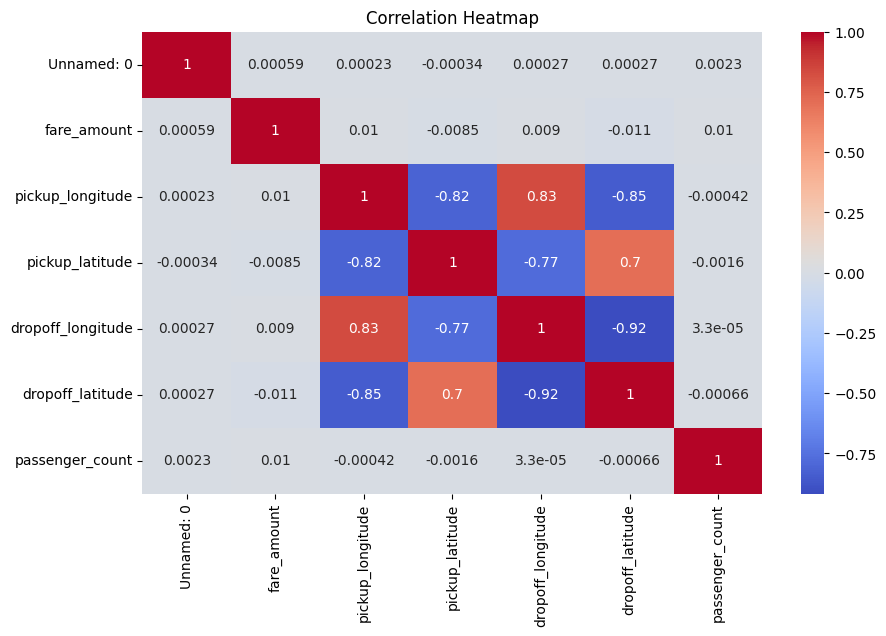

In [12]:
# Correlation matrix heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Function to replace outliers with using Inter Quartile Range (IQR) method
def replace_outliers_with_mean(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    mean_value = df[column].mean()
    df.loc[df[column] < lower_limit, column] = mean_value
    df.loc[df[column] > upper_limit, column] = mean_value
    return df

{'whiskers': [<matplotlib.lines.Line2D at 0x20c34a85810>,
 'caps': [<matplotlib.lines.Line2D at 0x20c34a85a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x20c34a856d0>],
 'medians': [<matplotlib.lines.Line2D at 0x20c34a85d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x20c34a85e50>],
 'means': []}

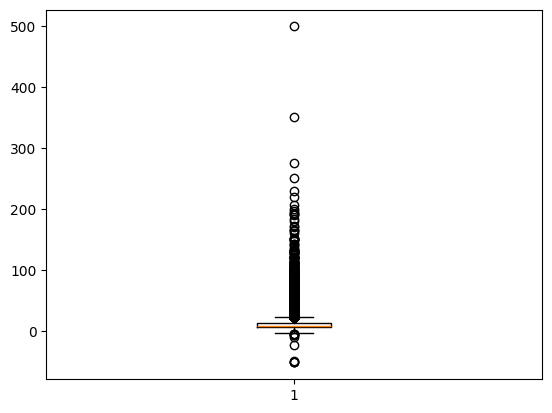

In [14]:
# Visual representation of outliers
plt.boxplot(df['fare_amount'])

In [15]:
df = replace_outliers_with_mean(df, 'fare_amount')

In [16]:
df = replace_outliers_with_mean(df, 'pickup_latitude')
df = replace_outliers_with_mean(df, 'pickup_longitude')
df = replace_outliers_with_mean(df, 'dropoff_latitude')
df = replace_outliers_with_mean(df, 'dropoff_longitude')

In [17]:
#Take x as predictor variable And y as target variable
x = df.drop(['fare_amount','pickup_datetime','key'], axis=1)
y = df['fare_amount']

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [19]:
# Apply linear Regression model
lrmodel=LinearRegression()
lrmodel.fit(x_train,y_train)

LinearRegression()

In [20]:
predict = lrmodel.predict(x_test)

In [21]:
# Evaluate the model
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predict)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 3.15
Mean Squared Error: 15.84
Root Mean Squared Error: 3.98
R-squared: 0.03


In [22]:
# Apply Random Forest Regressor
rfrmodel = RandomForestRegressor(n_estimators=10, random_state=101)

In [23]:
# Fit the Forest
rfrmodel.fit(x_train,y_train)
rfrmodel_pred = rfrmodel.predict(x_test)

In [24]:
# Evaluate the model
mae = mean_absolute_error(y_test, rfrmodel_pred)
mse = mean_squared_error(y_test, rfrmodel_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfrmodel_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 1.74
Mean Squared Error: 6.28
Root Mean Squared Error: 2.51
R-squared: 0.62
